In [1]:
import glob
import os.path as op
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.linear_model import LogisticRegression as LOR
from sklearn.model_selection import KFold
from sklearn.decomposition import PCA
from generalized_contrastive_PCA import gcPCA
from scipy.stats import median_abs_deviation as MAD

plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "cm",
})

In [2]:
def reject_outliers(X, m=3, scaling=False):
    """
    Adapted from https://medium.com/@saraswatp/exploring-data-anomalies-rejecting-outliers-with-python-660b1ed6bca6
    Returns a boolean mask where True = 'Keep' and False = 'Outlier'.
    """
    median = np.median(X, axis=0)
    # mad = MAD(X, axis=0, scale='normal')

    if scaling:
        mad = np.median(np.abs(X - median), axis=0) * 1.4826
    else:
        mad = np.median(np.abs(X - median), axis=0)
    
    upper_bound = median + m * mad
    lower_bound = median - m * mad

    mask = (X >= lower_bound) & (X <= upper_bound)

    return mask


def reject_outliers_by_subject_channel(burst_dict, value_key='peak_amp_base', m=3, scaling=False):
    """Compute outlier mask separately within each subject x chennel group.

    Args:
        burst_dict (dictionary): Burst dictionary containing at least:
            - 'subject'
            - 'channel'
            - value_key
        
        value_key (str, optional): Name of the feature on which to reject outliers. Defaults to 'peak_amp_base'.
        m (float, optional): Number of MADs from the median used as the cutoff. Defaults to 3.
        scaling (bool, optional): If True, scale MAD by 1.4826. Defaults to False.
    
    Returns:
        group_mask: ndarray of bool, shape (n_bursts,). Global mask with True = keep, False = outlier.
    """

    values = np.asarray(burst_dict[value_key])
    subjects_arr = np.asarray(burst_dict['subject'])
    channels_arr = np.asarray(burst_dict['channel'])

    n = len(values)
    if not (len(subjects_arr) == n and len(channels_arr) == n):
        raise ValueError(f"'subject', 'channel', and '{value_key}' must have the same length." )
    
    group_mask = np.ones(n, dtype=bool)
    unique_subjects = np.unique(subjects_arr)

    for sub in unique_subjects:
        sub_idx = subjects_arr == sub
        sub_channels = np.unique(channels_arr[sub_idx])

        for ch in sub_channels:
            idx = sub_idx & (channels_arr == ch)

            # Reject within this subject x channel subset
            local_mask = reject_outliers(values[idx], m=m, scaling=scaling)

            # Write local decisions back into full-length mask
            group_mask[idx] = local_mask

    return group_mask

In [3]:
def scaler_fit(X):
    median = np.median(X, axis=0)
    mad = MAD(X, axis=0, scale='normal')
    return median, mad


def scaler_transform(X, median, mad):
    return (X - median) / mad

In [4]:
def get_features_and_labels(gcPC_scores, bursts_dict, type_subs, cols_idx, n_bins, area):
    """
    Function to build the feature matrix and label vector for the logistic regression classifier.
    It takes as input the gcPC scores for all bursts, the bursts dictionary, the indices of the gcPCs
    to consider, the number of bins to use for each gcPC, the number of MADs to use for outlier
    rejection when building trial-level features, and the area to consider (STN or cortical).
    """
    
    max_type_subs = sum(len(np.unique(bursts_dict['trial'][bursts_dict['subject'] == sub])) for sub in type_subs)
    X = np.zeros((max_type_subs, len(cols_idx) * n_bins))
    y = np.zeros(max_type_subs)

    r = 0
    for i in range(len(type_subs)):
        type_sub = type_subs[i]
        
        # compute percentile bin limits using subject bursts only
        subject_bursts_idx = (bursts_dict['subject'] == type_sub) & area
        if np.sum(subject_bursts_idx) == 0:
            print(f'Warning: No bursts found for subject {type_sub} in the selected area ({area}). '
                  'Skipping this subject for percentile bin limit computation.')
            continue

        pc_bin_lims = np.zeros((len(cols_idx), n_bins + 1))
        for col_idx, col in enumerate(cols_idx):
            pc_bin_lims[col_idx, :] = np.percentile(gcPC_scores[subject_bursts_idx, col], np.linspace(0, 100, n_bins + 1))

        # Build trial-level features across all cortex trials
        trials = np.unique(bursts_dict['trial'][(bursts_dict['subject'] == type_sub)])
        for trial in trials:
            burst_idx = area & (bursts_dict['trial'] == trial) & (bursts_dict['subject'] == type_sub)
            label = np.unique(bursts_dict['med'][burst_idx])[0]
            
            row = np.zeros(len(cols_idx) * n_bins, dtype=float)  # Pre-allocate row with zeros for gcPC-bin combinations with no bursts
            for col_idx, col in enumerate(cols_idx):
                for bin in range(n_bins):
                    lower = pc_bin_lims[col_idx, bin]
                    higher = pc_bin_lims[col_idx, bin+1]
                    count = np.sum((gcPC_scores[burst_idx, col] >= lower) &
                                    (gcPC_scores[burst_idx, col] < higher))
                    row[col_idx * n_bins + bin] = count
            X[r, :] = row
            y[r] = 0 if label == 'OFF' else 1
            r += 1

    X = X[:r]
    y = y[:r]

    return X, y

### Channel labels

In [5]:
ch_labels = ['STN_L1', 'STN_L2', 'STN_L3', 'STN_L4', 'STN_R1', 'STN_R2', 'STN_R3', 'STN_R4', 'F3', 'Fz', 'F4', 'C3', 'C4', 'Cz']

### Subject labels

In [6]:
data_dir = '../../data/preprocessed_data/'
out_path = '../../data/derivatives/'
data_files = glob.glob(op.join(data_dir, 'dataClean_step1_*_MED_ON.mat'))
subjects = sorted([x.split('/')[-1].split('_')[3] for x in data_files])
print(subjects)

['s02', 's04', 's05', 's06', 's07', 's08', 's10', 's15', 's16', 's17', 's18']


### Aggregating burst features of the STN and of motor cortex (C3,C4) across all subjects

In [7]:
all_bursts={
    'subject': [],
    'med': [],
    'channel': [],
    'trial': [],
    'waveform': np.zeros((0,132)),
    'waveform_times': [],
    'peak_freq': [],
    'peak_amp_iter': [],
    'peak_amp_base': [],
    'peak_time': [],
    'peak_adjustment': [],
    'fwhm_freq': [],
    'fwhm_time': [],
    'polarity': [],
}

for subject in subjects:
    fname = op.join(out_path, 'beta', f'bursts_{subject}.pickle')
    if op.exists(fname):
        print(subject)
        with open(fname,'rb') as file:  # rb = read binary
            bursts = pickle.load(file)
        
        # stn_c_bursts = boolean containing True for STNs and C3, C4 and False for every other channels
        stn_c_bursts = np.char.startswith(bursts['channel'].astype(str), 'STN') | (bursts['channel']=='C3') | (bursts['channel']=='C4')
        
        # Loads the data from bursts to all_bursts
        for key in bursts.keys():
            if key=='waveform_times':
                all_bursts[key] = bursts[key]

            elif key=='waveform':
                all_bursts[key] = np.vstack([all_bursts[key], bursts[key][stn_c_bursts, :]])

            else:
                all_bursts[key] = np.hstack([all_bursts[key], bursts[key][stn_c_bursts]])

s02
s04
s05
s06
s07
s08
s10
s15
s16
s17
s18


In [8]:
for subject in subjects:
    subj_idx = (all_bursts['subject']==subject)
    off_med_trials = np.unique(all_bursts['trial'][subj_idx & (all_bursts['med']=='OFF')])
    max_off_trial = np.max(off_med_trials)
    on_med_idx = subj_idx & (all_bursts['med']=='ON')
    all_bursts['trial'][on_med_idx] = all_bursts['trial'][on_med_idx] + max_off_trial + 1 

In [9]:
burst_times = all_bursts['waveform_times'] * 1000 

In [10]:
outlier_mask = reject_outliers_by_subject_channel(
    all_bursts,
    value_key='peak_amp_base',
    m=3,
    scaling=False
    )

len_mask = len(outlier_mask)

correct_bursts = {
    key: (value[outlier_mask] if len(value) == len_mask else value)
    for key, value in all_bursts.items()
    }

# print(f"Original trials: {len(all_bursts['peak_amp_base'])}")
# print(f"Corrected trials: {len(correct_bursts['peak_amp_base'])}")
# print(f"Removed trials: {len(all_bursts['peak_amp_base']) - len(correct_bursts['peak_amp_base'])}")

### Select bursts corresponding to C3/C4 and all STN contacts

In [11]:
c_idx = (correct_bursts['channel']=='C3') | (correct_bursts['channel']=='C4')
stn_idx = [ch.startswith('STN') for ch in correct_bursts['channel']]

In [12]:
on_idx = (correct_bursts['med']=='ON')
off_idx = (correct_bursts['med']=='OFF')
on_c_idx = c_idx & on_idx
off_c_idx = c_idx & off_idx
on_stn_idx = stn_idx & on_idx
off_stn_idx = stn_idx & off_idx

In [13]:
"""
```scaling_method``` accepts: 
    - 'MAD-based',
    - 'Robust',
    - 'Standard'
"""
scaling_method = 'MAD-based'

area = stn_idx
scaled_waveforms = np.zeros_like(correct_bursts['waveform'])
for subject in np.unique(correct_bursts['subject']):
    subj_idx = (correct_bursts['subject'] == subject)

    if scaling_method == 'Robust':
        """Perform a modified z-score based on median and IQR"""
        scaler = RobustScaler().fit(correct_bursts['waveform'][subj_idx & area])                # .fit() returns the median and IQR values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'Standard':
        """Perform a z-score based on mean and STD"""
        scaler = StandardScaler().fit(correct_bursts['waveform'][subj_idx & area])              # .fit() returns the mean and STD values
        scaled_waveforms[subj_idx, :] = scaler.transform(correct_bursts['waveform'][subj_idx])  # .transform() does the maths.

    elif scaling_method == 'MAD-based':
        """Perfom a modified z-score based on median and MAD"""
        median, mad = scaler_fit(correct_bursts['waveform'][subj_idx & area])                   # Scaler based on MAD
        scaled_waveforms[subj_idx, :] = scaler_transform(correct_bursts['waveform'][subj_idx], median, mad)

    else:
        raise AttributeError("Wrong scaling method. Valide options are ['MAD-based', 'Robust', 'Standard'].")

### Group-level cross validation: split subjects into train/test groups
* 1/ Perfom both rPCA and gcPCA
* 2/ Each PC is binned
* 3/ Compute unique logit on each PCA, taking number of PCs and bins as features

In [ ]:
"""Parameters definition"""
area = stn_idx
subjects = np.array(subjects)

n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

n_bins = np.arange(1, 15, 1)     # Number of bins to divide PCs into

cols_rPC = np.arange(2, 21, 2)   # List of rPC axes to consider
# n_gcPCs = np.arange(1, 11, 1)    # Half number of gcPCs to consider - Un/comment to deal with all or specific number of gcPCs

cols_gcPC = [0, -1]
n_rPC = [0, 1, 2, 3]

# for n_gcPC, n_rPC in zip(n_gcPCs, cols_rPC):
"""Run mulitple cross-validation logits on PCA outputs for different number of PCs"""

# Un/comment to deal with all or specific number of gcPCs
# null_and_positive = np.arange(0, n_gcPC, 1)
# negative = np.arange(-n_gcPC, 0, 1)
# cols_gcPC = np.concatenate([null_and_positive, negative])

n_rPC = np.arange(n_rPC)
print("gcPCs:", cols_gcPC, len(cols_gcPC))
print("rPCs:", n_rPC, len(n_rPC))

# List creations to store accuracies and variances for both PCAs for a given number of PCs
rPCA_accuracy, rPCA_var = [], []
gcPCA_accuracy, gcPCA_var = [], []

# List creations to store coefficents and intercept for both PCAs for a given number of PCs
rPCA_intercept, rPCA_mean_coefs, rPCA_var_coefs = [], [], []
gcPCA_intercept, gcPCA_mean_coefs, gcPCA_var_coefs = [], [], []
for n_bin in n_bins:
    """Run multiple cross-validation logits on PCA outputs for different number of bins"""

    print(f'Bins: {n_bin}/{n_bins}')

    # Arrays creation to store accuracies for both PCAs for a given number of bins
    rPCA_fold_accuracies = np.zeros(n_splits)
    gcPCA_fold_accuracies = np.zeros(n_splits)

    # Arrays and lists creation to store coefficients and intercept for both PCAs for a given number of bins
    rPCA_fold_intercept = np.zeros(n_splits)
    rPCA_fold_coefs = []
    gcPCA_fold_intercept = np.zeros(n_splits)
    gcPCA_fold_coefs = []

    for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
        """Run cross-validation logits on PCA ouptuts"""

        # Training and testing sets creation
        train_subs = subjects[train_s_idx]
        test_subs = subjects[test_s_idx]
        # print(f'Fold {fold_idx}: Train subs: {train_subs}, Test subs: {test_subs}')

        # Select bursts from training subjects
        train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area
        train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
        train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')

        # Fit rPCA on training subjects' bursts
        rPCA_model = PCA(n_components=20, random_state=6)
        rPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :])
        # all_rPCA_scores = scaled_waveforms @ rPCA_model.components_.T
        all_rPCA_scores = rPCA_model.transform(scaled_waveforms)
        #-----------------------------------------------------------------------------------
        # Fit gcPCA on training subjects' bursts
        gcPCA_model = gcPCA(method='v4', normalize_flag=False)
        gcPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
        all_gcPCA_scores = scaled_waveforms @ gcPCA_model.loadings_

        """To un/comment if you want to use all gcPCs:"""
        # n_gcPC = gcPCA_model.loadings_.shape[1]
        # cols_gcPC = np.arange(0, n_gcPC, 1)

        """Get features and labels for logit from PCA outputs"""
        X_rPCA_train, y_rPCA_train = get_features_and_labels(all_rPCA_scores, correct_bursts, train_subs, n_rPC, n_bin, area)
        X_rPCA_test, y_rPCA_test = get_features_and_labels(all_rPCA_scores, correct_bursts, test_subs, n_rPC, n_bin, area)
        #-----------------------------------------------------------------------------------
        X_gcPCA_train, y_gcPCA_train = get_features_and_labels(all_gcPCA_scores, correct_bursts, train_subs, cols_gcPC, n_bin, area)
        X_gcPCA_test, y_gcPCA_test = get_features_and_labels(all_gcPCA_scores, correct_bursts, test_subs, cols_gcPC, n_bin, area)

        """Logistic regression on PCA outputs with increased maximum iterations"""
        model_rPCA = LOR(max_iter=10_000)
        model_rPCA = model_rPCA.fit(X_rPCA_train, y_rPCA_train)
        y_pred_rPCA = model_rPCA.predict(X_rPCA_test)
        #-----------------------------------------------------------------------------------
        model_gcPCA = LOR(max_iter=10_000)
        model_gcPCA = model_gcPCA.fit(X_gcPCA_train, y_gcPCA_train)
        y_pred_gcPCA = model_gcPCA.predict(X_gcPCA_test)

        """Store logit intercept and coefficients accordingly"""
        rPCA_fold_intercept[fold_idx] = model_rPCA.intercept_[0]
        rPCA_fold_coefs.append(model_rPCA.coef_[0])
        #-----------------------------------------------------------------------------------
        gcPCA_fold_intercept[fold_idx] = model_gcPCA.intercept_[0]
        gcPCA_fold_coefs.append(model_gcPCA.coef_[0])

        """Store logit accuracies accordingly"""
        rPCA_fold_accuracy = np.mean(y_rPCA_test == y_pred_rPCA)
        gcPCA_fold_accuracy = np.mean(y_gcPCA_test == y_pred_gcPCA)
        rPCA_fold_accuracies[fold_idx] = rPCA_fold_accuracy
        gcPCA_fold_accuracies[fold_idx] = gcPCA_fold_accuracy
        print(f'Fold {fold_idx}: gcPCA accuracy = {gcPCA_fold_accuracy:.3f}, rPCA accuracy = {rPCA_fold_accuracy:.3f}')

    """Store cross-validated logit accuracies accordingly"""
    rPCA_accuracy.append(np.mean(rPCA_fold_accuracies))
    rPCA_var.append(np.std(rPCA_fold_accuracies))
    #-----------------------------------------------------------------------------------
    gcPCA_accuracy.append(np.mean(gcPCA_fold_accuracies))
    gcPCA_var.append(np.std(gcPCA_fold_accuracies))
    print(f'Group-level CV: Mean gcPCA accuracy = {np.mean(gcPCA_fold_accuracies):.3f} ± {np.std(gcPCA_fold_accuracies):.3f}')
    print(f'Group-level CV: Mean rPCA accuracy = {np.mean(rPCA_fold_accuracies):.3f} ± {np.std(rPCA_fold_accuracies):.3f}')

    """Store cross-validated logit coefficients and intercept accordingly"""
    rPCA_intercept.append(np.mean(rPCA_fold_intercept))
    rPCA_mean_coefs.append(np.mean(np.vstack(rPCA_fold_coefs), axis=0))
    rPCA_var_coefs.append(np.std(np.vstack(rPCA_fold_coefs), axis=0))
    #-----------------------------------------------------------------------------------
    gcPCA_intercept.append(np.mean(gcPCA_fold_intercept))
    gcPCA_mean_coefs.append(np.mean(np.vstack(gcPCA_fold_coefs), axis=0))
    gcPCA_var_coefs.append(np.std(np.vstack(gcPCA_fold_coefs), axis=0))
    print(f'Group-level CV: Mean gcPCA intercept = {np.mean(gcPCA_fold_intercept):.3f} ± {np.std(gcPCA_fold_intercept):.3f}')
    print(f'Group-level CV: Mean gcPCA coefs = {np.round(np.mean(np.vstack(gcPCA_fold_coefs), axis=0), 3)} ± {np.round(np.std(np.vstack(gcPCA_fold_coefs), axis=0), 3)}')
    print(f'Group-level CV: Mean rPCA intercept = {np.mean(rPCA_fold_intercept):.3f} ± {np.std(rPCA_fold_intercept):.3f}')
    print(f'Group-level CV: Mean rPCA coefs = {np.round(np.mean(np.vstack(rPCA_fold_coefs), axis=0), 3)} ± {np.round(np.std(np.vstack(rPCA_fold_coefs), axis=0), 3)}\n')

"""Data saving"""
gcPC_file = op.join(f'best_gcPCA_outputs_{len(cols_gcPC)}_stn.npy')
rPC_file = op.join(f'bes_rPCA_outputs_{len(n_rPC)}_stn.npy')

if op.exists(gcPC_file):
    print(f"File {gcPC_file} already exists. Skipping saving.")
    pass
else:
    print(f"Saving file {gcPC_file}...")
    np.save(f'gcPCA_outputs_{len(cols_gcPC)}_stn', {
        'accuracy': gcPCA_accuracy,
        'variance': gcPCA_var,
        'intercept': gcPCA_intercept,
        'mean_coefficients': gcPCA_mean_coefs,
        'var_coefficients': gcPCA_var_coefs,
        'Metadata': {
            'n_bins': n_bins,
            'cols': cols_gcPC,
            'area': 'stn',
            'Parameters': [
                "Based on MAD-scaled waveforms",
                "Outlier rejection with m=3 MADs",
                "Logistic regression classifier with default parameters",
                "No X-row normalization",
                "No X scaling before classification"
            ]}})        
    if op.exists(gcPC_file):
        print(f"File {gcPC_file} successfully saved.")
    else:
        print(f"Error: File {gcPC_file} was not found.")

if op.exists(rPC_file):
    print(f"File {rPC_file} already exists. Skipping saving.")
    pass
else:
    print(f"Saving file {rPC_file}...")
    np.save(f'rPCA_outputs_{len(n_rPC)}_stn', {
        'accuracy': rPCA_accuracy,
        'variance': rPCA_var,
        'intercept': rPCA_intercept,
        'mean_coefficients': rPCA_mean_coefs,
        'var_coefficients': rPCA_var_coefs,
        'Metadata': {
            'n_bins': n_bins,
            'cols': n_rPC,
            'area': 'stn',
            'Parameters': [
                "Based on MAD-scaled waveforms",
                "Outlier rejection with m=3 MADs",
                "Logistic regression classifier with default parameters",
                "No X-row normalization",
                "No X scaling before classification"
            ]}})            
    if op.exists(rPC_file):
        print(f"File {rPC_file} successfully saved.")
    else:
        print(f"Error: File {rPC_file} was not found.")

print(f"{len(cols_gcPC)}/{n_gcPCs*2}")
print("_____________________________\n")

gcPCs: [ 0 -1] 2
rPCs: [0 1] 2
Bins: 1/[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Fold 0: gcPCA accuracy = 0.780, rPCA accuracy = 0.780
Fold 1: gcPCA accuracy = 0.795, rPCA accuracy = 0.795
Fold 2: gcPCA accuracy = 0.447, rPCA accuracy = 0.447
Fold 3: gcPCA accuracy = 0.632, rPCA accuracy = 0.632
Fold 4: gcPCA accuracy = 0.769, rPCA accuracy = 0.769
Fold 5: gcPCA accuracy = 0.421, rPCA accuracy = 0.395
Fold 6: gcPCA accuracy = 0.811, rPCA accuracy = 0.811
Fold 7: gcPCA accuracy = 0.757, rPCA accuracy = 0.757
Fold 8: gcPCA accuracy = 0.300, rPCA accuracy = 0.275
Fold 9: gcPCA accuracy = 0.333, rPCA accuracy = 0.300
Fold 10: gcPCA accuracy = 0.727, rPCA accuracy = 0.727
Group-level CV: Mean gcPCA accuracy = 0.616 ± 0.190
Group-level CV: Mean rPCA accuracy = 0.608 ± 0.201
Group-level CV: Mean gcPCA intercept = 3.112 ± 0.545
Group-level CV: Mean gcPCA coefs = [ 0.523 -0.581] ± [0.243 0.244]
Group-level CV: Mean rPCA intercept = 3.141 ± 0.561
Group-level CV: Mean rPCA coefs = [ 0.05  -0.10

In [83]:
"""Parameters definition"""
area = c_idx
subjects = np.array(subjects)

n_splits = len(subjects)
kf = KFold(n_splits=n_splits, shuffle=True, random_state=6)

n_bins = np.arange(1, 15, 1)     # Number of bins to divide PCs into

cols_rPC = np.arange(2, 21, 2)   # List of rPC axes to consider
n_gcPCs = np.arange(1, 11, 1)    # Half number of gcPCs to consider - Un/comment to deal with all or specific number of gcPCs

for n_gcPC, n_rPC in zip(n_gcPCs, cols_rPC):
    """Run mulitple cross-validation logits on PCA outputs for different number of PCs"""
    
    # Un/comment to deal with all or specific number of gcPCs
    null_and_positive = np.arange(0, n_gcPC, 1)
    negative = np.arange(-n_gcPC, 0, 1)
    cols_gcPC = np.concatenate([null_and_positive, negative])

    n_rPC = np.arange(n_rPC)
    print("gcPCs:", cols_gcPC, len(cols_gcPC))
    print("rPCs:", n_rPC, len(n_rPC))

    # List creations to store accuracies and variances for both PCAs for a given number of PCs
    rPCA_accuracy, rPCA_var = [], []
    gcPCA_accuracy, gcPCA_var = [], []

    # List creations to store coefficents and intercept for both PCAs for a given number of PCs
    rPCA_intercept, rPCA_mean_coefs, rPCA_var_coefs = [], [], []
    gcPCA_intercept, gcPCA_mean_coefs, gcPCA_var_coefs = [], [], []
    for n_bin in n_bins:
        """Run multiple cross-validation logits on PCA outputs for different number of bins"""

        print(f'Bins: {n_bin}/{n_bins}')

        # Arrays creation to store accuracies for both PCAs for a given number of bins
        rPCA_fold_accuracies = np.zeros(n_splits)
        gcPCA_fold_accuracies = np.zeros(n_splits)

        # Arrays and lists creation to store coefficients and intercept for both PCAs for a given number of bins
        rPCA_fold_intercept = np.zeros(n_splits)
        rPCA_fold_coefs = []
        gcPCA_fold_intercept = np.zeros(n_splits)
        gcPCA_fold_coefs = []

        for fold_idx, (train_s_idx, test_s_idx) in enumerate(kf.split(subjects)):
            """Run cross-validation logits on PCA ouptuts"""

            # Training and testing sets creation
            train_subs = subjects[train_s_idx]
            test_subs = subjects[test_s_idx]
            # print(f'Fold {fold_idx}: Train subs: {train_subs}, Test subs: {test_subs}')

            # Select bursts from training subjects
            train_bursts_idx = np.isin(correct_bursts['subject'], train_subs) & area
            train_bursts_on_idx = train_bursts_idx & (correct_bursts['med']=='ON')
            train_bursts_off_idx = train_bursts_idx & (correct_bursts['med']=='OFF')

            # Fit rPCA on training subjects' bursts
            rPCA_model = PCA(n_components=20, random_state=6)
            rPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :])
            # all_rPCA_scores = scaled_waveforms @ rPCA_model.components_.T
            all_rPCA_scores = rPCA_model.transform(scaled_waveforms)
            #-----------------------------------------------------------------------------------
            # Fit gcPCA on training subjects' bursts
            gcPCA_model = gcPCA(method='v4', normalize_flag=False)
            gcPCA_model.fit(scaled_waveforms[train_bursts_off_idx, :], scaled_waveforms[train_bursts_on_idx, :])
            all_gcPCA_scores = scaled_waveforms @ gcPCA_model.loadings_

            """To un/comment if you want to use all gcPCs:"""
            # n_gcPC = gcPCA_model.loadings_.shape[1]
            # cols_gcPC = np.arange(0, n_gcPC, 1)

            """Get features and labels for logit from PCA outputs"""
            X_rPCA_train, y_rPCA_train = get_features_and_labels(all_rPCA_scores, correct_bursts, train_subs, n_rPC, n_bin, area)
            X_rPCA_test, y_rPCA_test = get_features_and_labels(all_rPCA_scores, correct_bursts, test_subs, n_rPC, n_bin, area)
            #-----------------------------------------------------------------------------------
            X_gcPCA_train, y_gcPCA_train = get_features_and_labels(all_gcPCA_scores, correct_bursts, train_subs, cols_gcPC, n_bin, area)
            X_gcPCA_test, y_gcPCA_test = get_features_and_labels(all_gcPCA_scores, correct_bursts, test_subs, cols_gcPC, n_bin, area)

            """Logistic regression on PCA outputs with increased maximum iterations"""
            model_rPCA = LOR(max_iter=10_000)
            model_rPCA = model_rPCA.fit(X_rPCA_train, y_rPCA_train)
            y_pred_rPCA = model_rPCA.predict(X_rPCA_test)
            #-----------------------------------------------------------------------------------
            model_gcPCA = LOR(max_iter=10_000)
            model_gcPCA = model_gcPCA.fit(X_gcPCA_train, y_gcPCA_train)
            y_pred_gcPCA = model_gcPCA.predict(X_gcPCA_test)

            """Store logit intercept and coefficients accordingly"""
            rPCA_fold_intercept[fold_idx] = model_rPCA.intercept_[0]
            rPCA_fold_coefs.append(model_rPCA.coef_[0])
            #-----------------------------------------------------------------------------------
            gcPCA_fold_intercept[fold_idx] = model_gcPCA.intercept_[0]
            gcPCA_fold_coefs.append(model_gcPCA.coef_[0])

            """Store logit accuracies accordingly"""
            rPCA_fold_accuracy = np.mean(y_rPCA_test == y_pred_rPCA)
            gcPCA_fold_accuracy = np.mean(y_gcPCA_test == y_pred_gcPCA)
            rPCA_fold_accuracies[fold_idx] = rPCA_fold_accuracy
            gcPCA_fold_accuracies[fold_idx] = gcPCA_fold_accuracy
            print(f'Fold {fold_idx}: gcPCA accuracy = {gcPCA_fold_accuracy:.3f}, rPCA accuracy = {rPCA_fold_accuracy:.3f}')

        """Store cross-validated logit accuracies accordingly"""
        rPCA_accuracy.append(np.mean(rPCA_fold_accuracies))
        rPCA_var.append(np.std(rPCA_fold_accuracies))
        #-----------------------------------------------------------------------------------
        gcPCA_accuracy.append(np.mean(gcPCA_fold_accuracies))
        gcPCA_var.append(np.std(gcPCA_fold_accuracies))
        print(f'Group-level CV: Mean gcPCA accuracy = {np.mean(gcPCA_fold_accuracies):.3f} ± {np.std(gcPCA_fold_accuracies):.3f}')
        print(f'Group-level CV: Mean rPCA accuracy = {np.mean(rPCA_fold_accuracies):.3f} ± {np.std(rPCA_fold_accuracies):.3f}')

        """Store cross-validated logit coefficients and intercept accordingly"""
        rPCA_intercept.append(np.mean(rPCA_fold_intercept))
        rPCA_mean_coefs.append(np.mean(np.vstack(rPCA_fold_coefs), axis=0))
        rPCA_var_coefs.append(np.std(np.vstack(rPCA_fold_coefs), axis=0))
        #-----------------------------------------------------------------------------------
        gcPCA_intercept.append(np.mean(gcPCA_fold_intercept))
        gcPCA_mean_coefs.append(np.mean(np.vstack(gcPCA_fold_coefs), axis=0))
        gcPCA_var_coefs.append(np.std(np.vstack(gcPCA_fold_coefs), axis=0))
        print(f'Group-level CV: Mean gcPCA intercept = {np.mean(gcPCA_fold_intercept):.3f} ± {np.std(gcPCA_fold_intercept):.3f}')
        print(f'Group-level CV: Mean gcPCA coefs = {np.round(np.mean(np.vstack(gcPCA_fold_coefs), axis=0), 3)} ± {np.round(np.std(np.vstack(gcPCA_fold_coefs), axis=0), 3)}')
        print(f'Group-level CV: Mean rPCA intercept = {np.mean(rPCA_fold_intercept):.3f} ± {np.std(rPCA_fold_intercept):.3f}')
        print(f'Group-level CV: Mean rPCA coefs = {np.round(np.mean(np.vstack(rPCA_fold_coefs), axis=0), 3)} ± {np.round(np.std(np.vstack(rPCA_fold_coefs), axis=0), 3)}\n')

    """Data saving"""
    gcPC_file = op.join(f'gcPCA_outputs_{len(cols_gcPC)}_ctx.npy')
    rPC_file = op.join(f'rPCA_outputs_{len(n_rPC)}_ctx.npy')

    if op.exists(gcPC_file):
        print(f"File {gcPC_file} already exists. Skipping saving.")
        pass
    else:
        print(f"Saving file {gcPC_file}...")
        np.save(f'gcPCA_outputs_{len(cols_gcPC)}_ctx', {
            'accuracy': gcPCA_accuracy,
            'variance': gcPCA_var,
            'intercept': gcPCA_intercept,
            'mean_coefficients': gcPCA_mean_coefs,
            'var_coefficients': gcPCA_var_coefs,
            'Metadata': {
                'n_bins': n_bins,
                'cols': cols_gcPC,
                'area': 'ctx',
                'Parameters': [
                    "Based on MAD-scaled waveforms",
                    "Outlier rejection with m=3 MADs",
                    "Logistic regression classifier with default parameters",
                    "No X-row normalization",
                    "No X scaling before classification"
                ]}})        
        if op.exists(gcPC_file):
            print(f"File {gcPC_file} successfully saved.")
        else:
            print(f"Error: File {gcPC_file} was not found.")

    if op.exists(rPC_file):
        print(f"File {rPC_file} already exists. Skipping saving.")
        pass
    else:
        print(f"Saving file {rPC_file}...")
        np.save(f'rPCA_outputs_{len(n_rPC)}_ctx', {
            'accuracy': rPCA_accuracy,
            'variance': rPCA_var,
            'intercept': rPCA_intercept,
            'mean_coefficients': rPCA_mean_coefs,
            'var_coefficients': rPCA_var_coefs,
            'Metadata': {
                'n_bins': n_bins,
                'cols': n_rPC,
                'area': 'ctx',
                'Parameters': [
                    "Based on MAD-scaled waveforms",
                    "Outlier rejection with m=3 MADs",
                    "Logistic regression classifier with default parameters",
                    "No X-row normalization",
                    "No X scaling before classification"
                ]}})            
        if op.exists(rPC_file):
            print(f"File {rPC_file} successfully saved.")
        else:
            print(f"Error: File {rPC_file} was not found.")
    
    print(f"{len(cols_gcPC)}/{n_gcPCs*2}")
    print("_____________________________\n")

gcPCs: [ 0 -1] 2
rPCs: [0 1] 2
Bins: 1/[ 1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Fold 0: gcPCA accuracy = 0.585, rPCA accuracy = 0.561
Fold 1: gcPCA accuracy = 0.821, rPCA accuracy = 0.795
Fold 2: gcPCA accuracy = 0.500, rPCA accuracy = 0.500
Fold 3: gcPCA accuracy = 0.632, rPCA accuracy = 0.658
Fold 4: gcPCA accuracy = 0.667, rPCA accuracy = 0.692
Fold 5: gcPCA accuracy = 0.368, rPCA accuracy = 0.368
Fold 6: gcPCA accuracy = 0.865, rPCA accuracy = 0.838
Fold 7: gcPCA accuracy = 0.541, rPCA accuracy = 0.541
Fold 8: gcPCA accuracy = 0.700, rPCA accuracy = 0.700
Fold 9: gcPCA accuracy = 0.400, rPCA accuracy = 0.367
Fold 10: gcPCA accuracy = 0.697, rPCA accuracy = 0.727
Group-level CV: Mean gcPCA accuracy = 0.616 ± 0.150
Group-level CV: Mean rPCA accuracy = 0.613 ± 0.152
Group-level CV: Mean gcPCA intercept = 2.572 ± 0.295
Group-level CV: Mean gcPCA coefs = [ 0.503 -0.701] ± [0.207 0.199]
Group-level CV: Mean rPCA intercept = 2.646 ± 0.292
Group-level CV: Mean rPCA coefs = [ 0.265 -0.46

### Plot logit accuracies with error bars (standard error of the mean across folds) as a function of the number of bins used for PC features

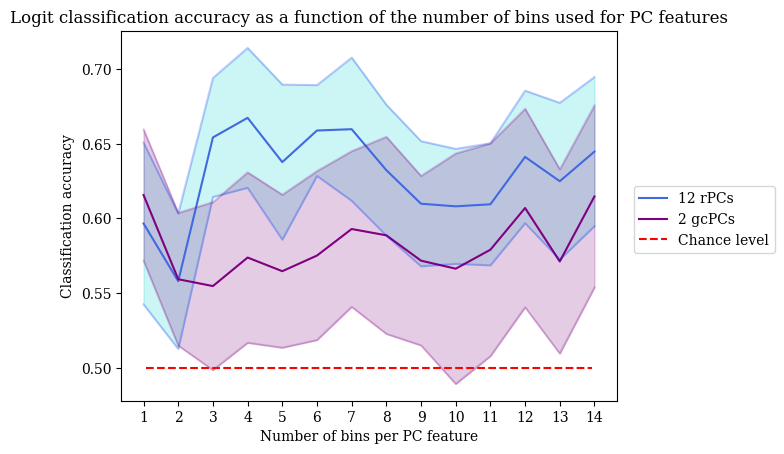

In [32]:
"""To import data"""
# rPCA_accuracy = np.load('rPCA_outputs.npy', allow_pickle=True).item()['accuracy']
# rPCA_var = np.load('rPCA_outputs.npy', allow_pickle=True).item()['variance']

rPCA_upper = np.array(rPCA_accuracy) + np.array(rPCA_var) / np.sqrt(n_splits)
rPCA_lower = np.array(rPCA_accuracy) - np.array(rPCA_var) / np.sqrt(n_splits)
gcPCA_upper = np.array(gcPCA_accuracy) + np.array(gcPCA_var) / np.sqrt(n_splits)
gcPCA_lower = np.array(gcPCA_accuracy) - np.array(gcPCA_var) / np.sqrt(n_splits)

plt.plot(rPCA_accuracy, color='royalblue', label='12 rPCs')  # Warning: Wrong labels
plt.plot(gcPCA_accuracy, color='purple', label='2 gcPCs')    # Warning: Wrong labels

plt.plot(rPCA_upper, color='blue', alpha=0.2)
plt.plot(rPCA_lower, color='blue',alpha=0.2)
plt.plot(gcPCA_upper, color='purple', alpha=0.2)
plt.plot(gcPCA_lower, color='purple',alpha=0.2)

plt.fill_between(n_bins-1, rPCA_lower, rPCA_upper, color='darkturquoise', alpha=0.2)
plt.fill_between(n_bins-1, gcPCA_lower, gcPCA_upper, color='purple', alpha=0.2)

plt.axhline(0.5, xmin=0.05, xmax=0.95, color='red', linestyle='--', label='Chance level')
plt.xlabel('Number of bins per PC feature')
plt.xticks(n_bins-1, labels=[f'{int(x+1)}' for x in n_bins-1])
plt.ylabel('Classification accuracy')
plt.title('Logit classification accuracy as a function of the number of bins used for PC features')
plt.legend(bbox_to_anchor=(1.02, 0.6))
plt.show()